# Exploratory Data Analysis

## Questions to solve:

- Are all features numeric? 
- Are there strings?
- Missing values?
- Data types?
- Scaling is needed?
- Cols with Negative Values?
- Any Constant column?

### Strategy

Use different Pandas methods to evaluate every question
  

In [2]:
# Read data, get features set, and add headers

#libraries
import pandas as pd
from pathlib import Path

N_FEATURES = 27
N_TARGETS = 7

notebook_dir = Path.cwd().parent

data_file = notebook_dir / "data" / "raw" / "Faults.NNA"
print(f'Data path: {data_file}')

data_names_file = notebook_dir / "data" / "Faults27x7_var"
print(f'Data names path: {data_names_file}')

with open(data_names_file, 'r') as f:
    names_list = f.read().splitlines() 


df_data = pd.read_csv(data_file, sep='\t', keep_default_na=False, header=None, names=names_list)
df_data_features = df_data.iloc[:, :N_FEATURES]

print(df_data_features.info())


Data path: D:\Desktop\TRaining\steel-defect-api\data\raw\Faults.NNA
Data names path: D:\Desktop\TRaining\steel-defect-api\data\Faults27x7_var
<class 'pandas.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 n

## Data features information:

#### memory usage 
409.6 KB

#### dtypes
- features(0-13): int64
- features(14-26): float64

#### non-null
- features(0-26): 1941

### Conclusion
- There are no string variables. 
- There are no null values, therefore "imputation" process is not needed.

In [58]:
# Get descriptive information of the features

print(df_data_features.describe())

         X_Minimum    X_Maximum     Y_Minimum     Y_Maximum   Pixels_Areas  \
count  1941.000000  1941.000000  1.941000e+03  1.941000e+03    1941.000000   
mean    571.136012   617.964451  1.650685e+06  1.650739e+06    1893.878413   
std     520.690671   497.627410  1.774578e+06  1.774590e+06    5168.459560   
min       0.000000     4.000000  6.712000e+03  6.724000e+03       2.000000   
25%      51.000000   192.000000  4.712530e+05  4.712810e+05      84.000000   
50%     435.000000   467.000000  1.204128e+06  1.204136e+06     174.000000   
75%    1053.000000  1072.000000  2.183073e+06  2.183084e+06     822.000000   
max    1705.000000  1713.000000  1.298766e+07  1.298769e+07  152655.000000   

        X_Perimeter   Y_Perimeter  Sum_of_Luminosity  Minimum_of_Luminosity  \
count   1941.000000   1941.000000       1.941000e+03            1941.000000   
mean     111.855229     82.965997       2.063121e+05              84.548686   
std      301.209187    426.482879       5.122936e+05        

## Scale of data

### Description

Features descriptors show a significant variability among them.

#### Example 
feature  2(Y_Minimum): mean= 1.650685e+06 , std= 1.774578e+06 \
feature 25(Luminosity_Index): mean= -0.131305    , std= 0.148767 

### Conclusion

Large differences between their means and std's values. A scaling process is needed.



In [60]:
## Get null values

print(f'Null elements:\n {df_data_features.isnull().sum()}')

Null elements:
 X_Minimum                0
X_Maximum                0
Y_Minimum                0
Y_Maximum                0
Pixels_Areas             0
X_Perimeter              0
Y_Perimeter              0
Sum_of_Luminosity        0
Minimum_of_Luminosity    0
Maximum_of_Luminosity    0
Length_of_Conveyer       0
TypeOfSteel_A300         0
TypeOfSteel_A400         0
Steel_Plate_Thickness    0
Edges_Index              0
Empty_Index              0
Square_Index             0
Outside_X_Index          0
Edges_X_Index            0
Edges_Y_Index            0
Outside_Global_Index     0
LogOfAreas               0
Log_X_Index              0
Log_Y_Index              0
Orientation_Index        0
Luminosity_Index         0
SigmoidOfAreas           0
dtype: int64


In [61]:
# Get duplicated instances

print(f'Duplicated instances: \n {df_data_features.duplicated().sum()}')


Duplicated instances: 
 0


## Duplicates: 
0
## Null values:
0

## Conclusion

All the instances are uniques, and all their values are non-null. Therefore, depuration is not needed.  



In [62]:
# Get Negative values

print(f'Instances with negative values: {(df_data_features < 0).any(axis=0).sum()} \n {(df_data_features < 0).any(axis=0)}')

Instances with negative values: 2 
 X_Minimum                False
X_Maximum                False
Y_Minimum                False
Y_Maximum                False
Pixels_Areas             False
X_Perimeter              False
Y_Perimeter              False
Sum_of_Luminosity        False
Minimum_of_Luminosity    False
Maximum_of_Luminosity    False
Length_of_Conveyer       False
TypeOfSteel_A300         False
TypeOfSteel_A400         False
Steel_Plate_Thickness    False
Edges_Index              False
Empty_Index              False
Square_Index             False
Outside_X_Index          False
Edges_X_Index            False
Edges_Y_Index            False
Outside_Global_Index     False
LogOfAreas               False
Log_X_Index              False
Log_Y_Index              False
Orientation_Index         True
Luminosity_Index          True
SigmoidOfAreas           False
dtype: bool


In [11]:
# Get the list of features with binary values (0,1)


binary_cols = [col for col in df_data_features.columns if df_data_features[col].nunique() <= 10]

binary_cols_01 = [
    col for col in df_data_features.columns 
    if set(df_data_features[col].dropna().unique()).issubset({0, 1})
]

print(f'Features with binary values {binary_cols}')
print(f'Features with binary values (0, 1) {binary_cols_01}')

print(df_data_features['Outside_Global_Index'].unique())
df_data_features["Outside_Global_Index"].value_counts().sort_index()
df_data_features['TypeOfSteel_A300'].value_counts()
df_data_features['TypeOfSteel_A400'].value_counts()


Features with binary values ['TypeOfSteel_A300', 'TypeOfSteel_A400', 'Outside_Global_Index']
Features with binary values (0, 1) ['TypeOfSteel_A300', 'TypeOfSteel_A400']
[1.  0.5 0. ]


TypeOfSteel_A400
1    1164
0     777
Name: count, dtype: int64

In [63]:
# Evaluate if a column (feature) has a constant value in all the instances

df_data_features.eq(df_data_features.iloc[0], axis=1).all()


X_Minimum                False
X_Maximum                False
Y_Minimum                False
Y_Maximum                False
Pixels_Areas             False
X_Perimeter              False
Y_Perimeter              False
Sum_of_Luminosity        False
Minimum_of_Luminosity    False
Maximum_of_Luminosity    False
Length_of_Conveyer       False
TypeOfSteel_A300         False
TypeOfSteel_A400         False
Steel_Plate_Thickness    False
Edges_Index              False
Empty_Index              False
Square_Index             False
Outside_X_Index          False
Edges_X_Index            False
Edges_Y_Index            False
Outside_Global_Index     False
LogOfAreas               False
Log_X_Index              False
Log_Y_Index              False
Orientation_Index        False
Luminosity_Index         False
SigmoidOfAreas           False
dtype: bool

## Features with Negative Values:

- **24**: Orientation_Index
- **25**: Luminosity_Index

## Features with constant value:
0

## Conlusion
- Only two variables have negative values. 
- The dataset does not contain features with a constant value.
- An analysis of the physical limits of the features is required to detect errors in the values.

# Target Analysis


In [65]:
# Get info of the targets

df_data_targets = df_data.iloc[:, -N_TARGETS:]

print(df_data_targets.info())
print(df_data_targets.head(3))

<class 'pandas.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Pastry        1941 non-null   int64
 1   Z_Scratch     1941 non-null   int64
 2   K_Scatch      1941 non-null   int64
 3   Stains        1941 non-null   int64
 4   Dirtiness     1941 non-null   int64
 5   Bumps         1941 non-null   int64
 6   Other_Faults  1941 non-null   int64
dtypes: int64(7)
memory usage: 106.3 KB
None
   Pastry  Z_Scratch  K_Scatch  Stains  Dirtiness  Bumps  Other_Faults
0       1          0         0       0          0      0             0
1       1          0         0       0          0      0             0
2       1          0         0       0          0      0             0


## Data target information:

### memory usage 
106.3 KB

### dtypes
- targets(0-6): int64

### non-null
- targets(0-6): 1941

## Conclusion
The target is composed of 7 classes. The classes have a binary value. For each instance, only one of the classes has a positive value (1), while the others have a negative value (0).

## Classes balance



In [66]:
# Get the number of instances with value True for every class

print(f' Number of instances for target: \n {df_data_targets.sum()}')

 Number of instances for target: 
 Pastry          158
Z_Scratch       190
K_Scatch        391
Stains           72
Dirtiness        55
Bumps           402
Other_Faults    673
dtype: int64


<Axes: title={'center': 'Number of instances Per class'}>

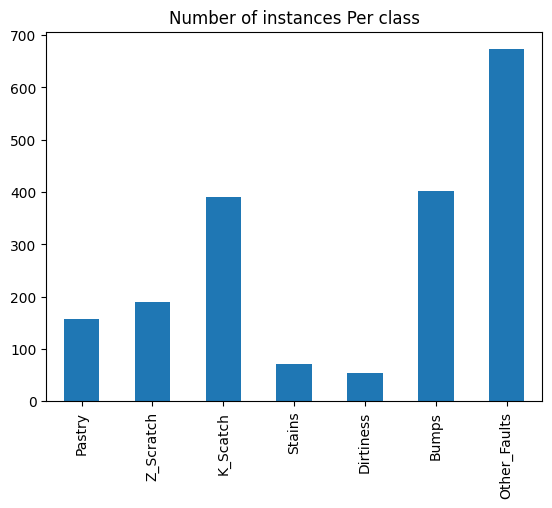

In [67]:
#Get histogram

df_data_targets.sum().plot(kind='bar', title='Number of instances Per class')



### Description 
A clear difference is observed in the number of instances per class, where the largest class contains approximately twelve times more samples than the smallest.

#### Example

- Dirtiness : 55
- Other_Faults : 673

### Conclusion

The dataset is imbalanced


# Feature analysis

For each feature determine:

- How is it distributed?
- Normal?
- Skewed?
- Outliers?

### Strategy

Since there are few features, we can get the boxplot for each one. Although skewness and outliers can be observed directly in the boxplot, we are going to get the skewness value for each instance, and also, to check the root of outliers to have a closer conclusion. 

X_Minimum                   Axes(0.125,0.653529;0.0731132x0.226471)
X_Maximum                Axes(0.212736,0.653529;0.0731132x0.226471)
Y_Minimum                Axes(0.300472,0.653529;0.0731132x0.226471)
Y_Maximum                Axes(0.388208,0.653529;0.0731132x0.226471)
Pixels_Areas             Axes(0.475943,0.653529;0.0731132x0.226471)
X_Perimeter              Axes(0.563679,0.653529;0.0731132x0.226471)
Y_Perimeter              Axes(0.651415,0.653529;0.0731132x0.226471)
Sum_of_Luminosity        Axes(0.739151,0.653529;0.0731132x0.226471)
Minimum_of_Luminosity    Axes(0.826887,0.653529;0.0731132x0.226471)
Maximum_of_Luminosity       Axes(0.125,0.381765;0.0731132x0.226471)
Length_of_Conveyer       Axes(0.212736,0.381765;0.0731132x0.226471)
TypeOfSteel_A300         Axes(0.300472,0.381765;0.0731132x0.226471)
TypeOfSteel_A400         Axes(0.388208,0.381765;0.0731132x0.226471)
Steel_Plate_Thickness    Axes(0.475943,0.381765;0.0731132x0.226471)
Edges_Index              Axes(0.563679,0.381765;

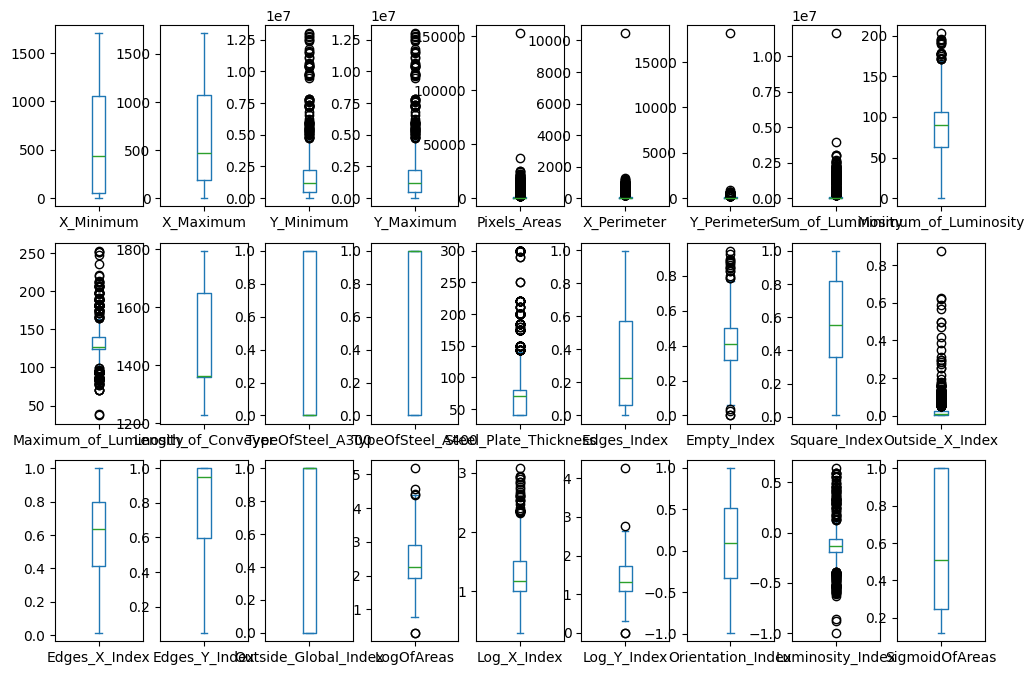

In [68]:
# Get boxplot per feature

df_data_features.plot(kind='box', subplots=True, layout=(3, 9), figsize=(12, 8), sharex=False, sharey=False)


In [69]:
# Get skewness value per feature 

df_data_features.skew()

X_Minimum                 0.500897
X_Maximum                 0.524210
Y_Minimum                 2.811213
Y_Maximum                 2.811169
Pixels_Areas             14.083822
X_Perimeter              21.539451
Y_Perimeter              39.293158
Sum_of_Luminosity         7.730720
Minimum_of_Luminosity    -0.107098
Maximum_of_Luminosity     1.287035
Length_of_Conveyer        0.851422
TypeOfSteel_A300          0.407249
TypeOfSteel_A400         -0.407249
Steel_Plate_Thickness     2.206935
Edges_Index               0.685771
Empty_Index               0.293468
Square_Index             -0.056306
Outside_X_Index           5.181830
Edges_X_Index            -0.235096
Edges_Y_Index            -0.928582
Outside_Global_Index     -0.306422
LogOfAreas                0.748284
Log_X_Index               1.001014
Log_Y_Index               0.445101
Orientation_Index        -0.153446
Luminosity_Index          0.679339
SigmoidOfAreas            0.125789
dtype: float64

## Skewness
### Result
Several features resulted in a high value of skewness > abs(0.5). Being the highest with a value of 39.293158. 

### Conclusion
Several continuous variables exhibit moderate to high skewness. Because the baseline model has not yet been selected, no transformations will be applied during EDA. Distribution transformations and feature scaling will be evaluated during preprocessing depending on the selected algorithm.

## Outliers

### Results
The boxplot graphs depict the existency of outliers

### Conclusion

Despite the boxplot graphs depict the existency of outliers based on "Tukey outlier rule":  values > 1.5*IQ. They could be potential characteristics of defective steel plates rather than obvious data quality issues.

In the boxplots we can observe one isolated element in 4 of the features: Pixels_Areas, X_Perimeter, Y_Perimeter, and Sum_of_Luminosity. In order to see if they belong to the same instance we get the index of the highest values.

In [71]:
# Get the index of the maximum value per feature

df_data_features.idxmax()


X_Minimum                1527
X_Maximum                1527
Y_Minimum                 149
Y_Maximum                 149
Pixels_Areas              391
X_Perimeter               391
Y_Perimeter               391
Sum_of_Luminosity         391
Minimum_of_Luminosity    1395
Maximum_of_Luminosity    1458
Length_of_Conveyer       1143
TypeOfSteel_A300            0
TypeOfSteel_A400            3
Steel_Plate_Thickness    1479
Edges_Index              1629
Empty_Index               391
Square_Index               48
Outside_X_Index          1382
Edges_X_Index              25
Edges_Y_Index               0
Outside_Global_Index        0
LogOfAreas                391
Log_X_Index              1382
Log_Y_Index               391
Orientation_Index         391
Luminosity_Index         1395
SigmoidOfAreas              4
dtype: int64

In [72]:
# Get the index of the minimum value per feature

df_data_features.idxmin()

X_Minimum                  38
X_Maximum                1310
Y_Minimum                1460
Y_Maximum                1460
Pixels_Areas              621
X_Perimeter               621
Y_Perimeter               621
Sum_of_Luminosity         654
Minimum_of_Luminosity     391
Maximum_of_Luminosity    1676
Length_of_Conveyer        877
TypeOfSteel_A300            3
TypeOfSteel_A400            0
Steel_Plate_Thickness       5
Edges_Index                38
Empty_Index               621
Square_Index              391
Outside_X_Index           621
Edges_X_Index             391
Edges_Y_Index            1863
Outside_Global_Index       56
LogOfAreas                621
Log_X_Index               621
Log_Y_Index               621
Orientation_Index        1863
Luminosity_Index          518
SigmoidOfAreas            621
dtype: int64

In [74]:
#print(df_data_features.iloc[390])
print(f'Class of the 390 instance:\n {df_data_targets.iloc[390]}')
print(f'Class of the 621 instance:\n {df_data_targets.iloc[621]}')

Class of the 390 instance:
 Pastry          0
Z_Scratch       0
K_Scatch        1
Stains          0
Dirtiness       0
Bumps           0
Other_Faults    0
Name: 390, dtype: int64
Class of the 621 instance:
 Pastry          0
Z_Scratch       0
K_Scatch        1
Stains          0
Dirtiness       0
Bumps           0
Other_Faults    0
Name: 621, dtype: int64


## Potential outliers:

### Notes
Instance 390 represents an extreme observation according to the IQR criterion. Its values represent the highest value for 8 of the features. 

Class = "K_scatch"

Instance 621 represents an extreme observation according to the IQR criterion. Its values represent the lowest value for 8 of the features. 

Class = "K_scatch"

## Feature Analysis Summary

- The dataset contains three binary features that will be retained without transformation.
- Most continuous features show varying numerical ranges, indicating that feature scaling may be required for algorithms sensitive to feature magnitude.
- Approximately fifteen features contain observations beyond the interquartile range. These values are considered potential characteristics of defective steel plates rather than obvious data quality issues, so no outlier removal is proposed at this stage.
- Two instances require a deeper revision to evaluate if they are or are not outliers.
- Several continuous features exhibit skewed distributions. Distribution transformations will be considered during preprocessing if required by the selected baseline model.
    

# Feature Relationships
### Objective

#### Answer questions such as:

- Are some features highly correlated?
- Are there redundant features?
- Should we consider feature selection later?
- Is there evidence of multicollinearity?

### Strategy

Get the correlation matrix and the sorted list of feature pairs.



In [51]:
correlation_matrix = df_data_features.corr(numeric_only=True)

correlation_matrix.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas
X_Minimum,1.000000,0.988311,0.041431,0.041417,-0.307576,-0.259178,-0.118837,-0.339333,0.237565,-0.076225,...,-0.361533,0.154531,0.368483,0.147812,-0.428712,-0.438623,-0.326684,0.179502,-0.032160,-0.355351
X_Maximum,0.988311,1.000000,0.051715,0.051703,-0.225666,-0.186579,-0.090222,-0.247352,0.168553,-0.063135,...,-0.215302,0.148983,0.272520,0.099824,-0.332331,-0.324717,-0.265787,0.115986,-0.039654,-0.286838
Y_Minimum,0.041431,0.051715,1.000000,1.000000,0.017547,0.023721,0.024117,0.007221,-0.065821,-0.068297,...,0.053981,0.065870,-0.036235,-0.062581,0.044925,0.070072,-0.008232,-0.085970,-0.091126,0.025257
Y_Maximum,0.041417,0.051703,1.000000,1.000000,0.017717,0.023916,0.024348,0.007358,-0.065851,-0.068287,...,0.054002,0.065836,-0.036241,-0.062571,0.044967,0.070097,-0.008172,-0.085952,-0.091138,0.025284
Pixels_Areas,-0.307576,-0.225666,0.017547,0.017717,1.000000,0.966642,0.827207,0.978951,-0.497269,0.109913,...,0.588578,-0.294799,-0.463530,-0.109536,0.650238,0.603067,0.578485,-0.137445,-0.043637,0.422957


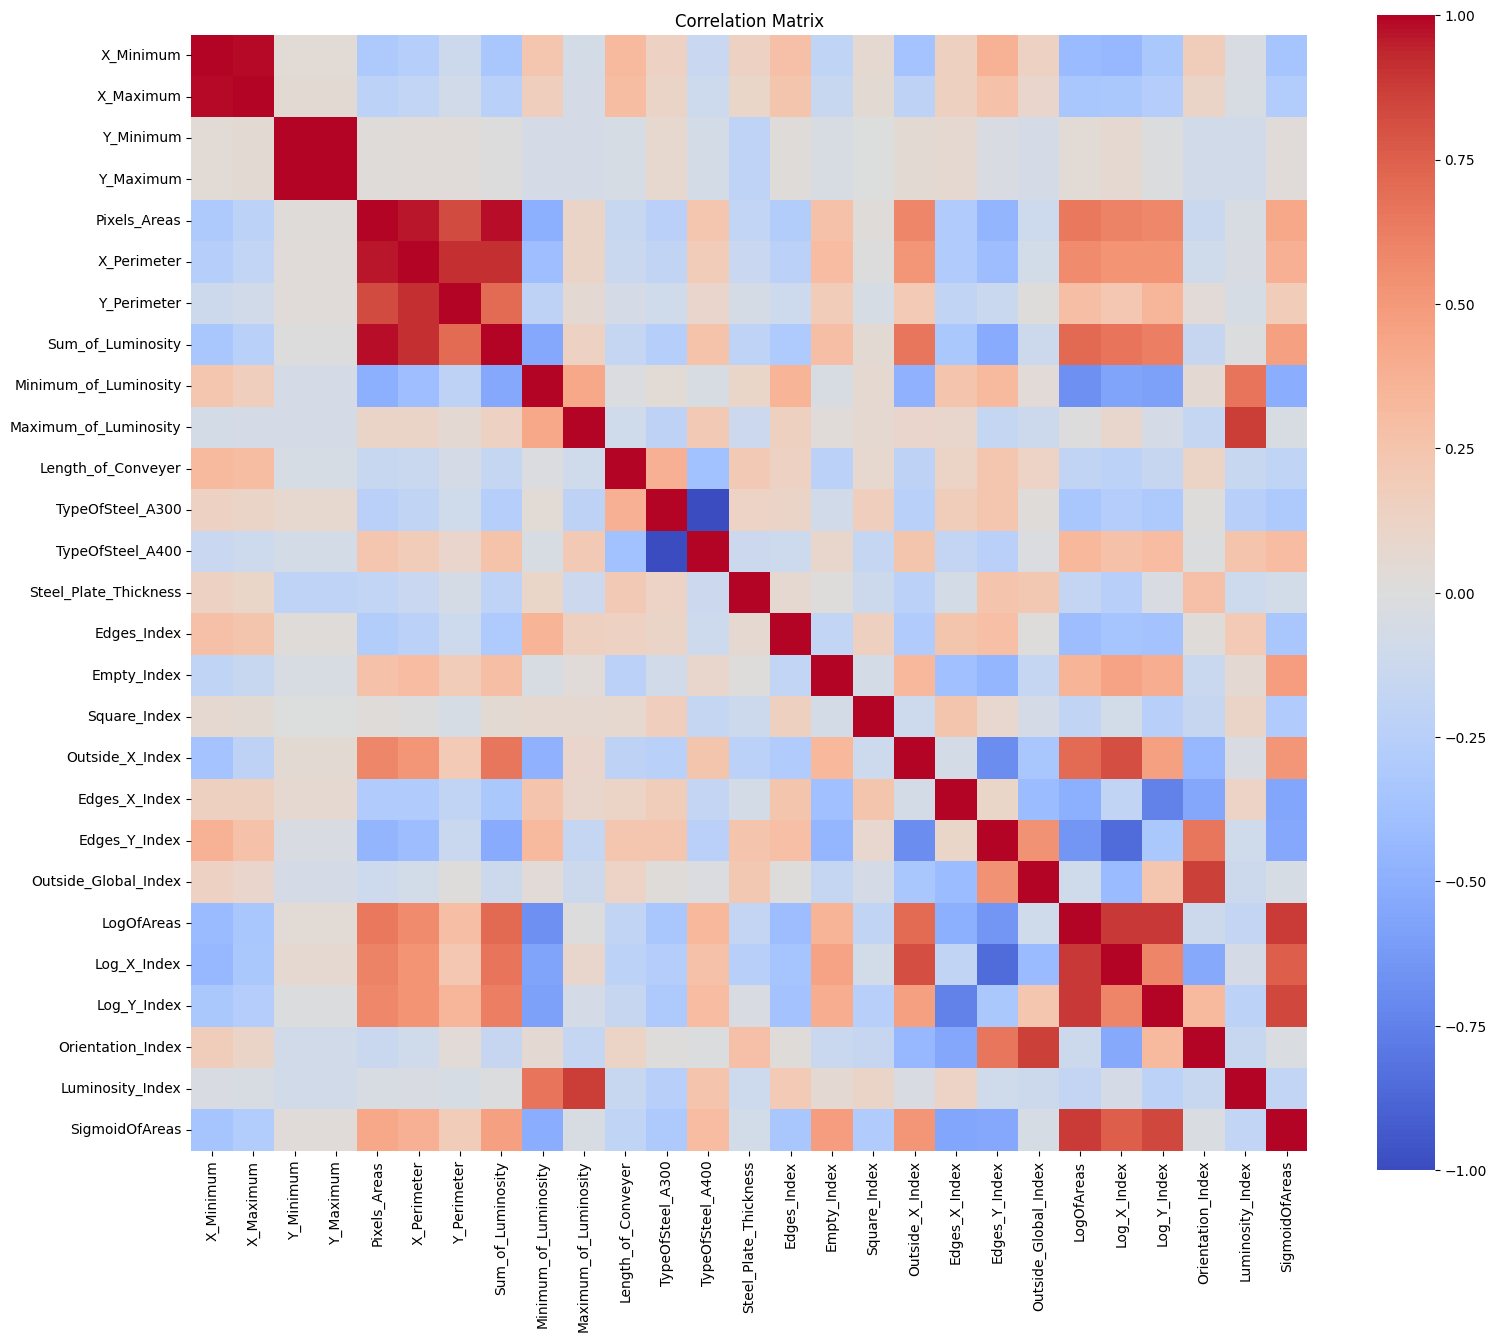

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 15))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix")
plt.show()

In [55]:
import numpy as np
corr = correlation_matrix.abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

strong_corr = upper.stack().sort_values(ascending=False)

strong_corr.head(50)

TypeOfSteel_A300       TypeOfSteel_A400         1.000000
Y_Minimum              Y_Maximum                1.000000
X_Minimum              X_Maximum                0.988311
Pixels_Areas           Sum_of_Luminosity        0.978951
                       X_Perimeter              0.966642
X_Perimeter            Sum_of_Luminosity        0.912951
                       Y_Perimeter              0.912447
LogOfAreas             Log_X_Index              0.889067
                       Log_Y_Index              0.883062
                       SigmoidOfAreas           0.877769
Maximum_of_Luminosity  Luminosity_Index         0.870077
Outside_Global_Index   Orientation_Index        0.862655
Edges_Y_Index          Log_X_Index              0.855363
Log_Y_Index            SigmoidOfAreas           0.838251
Pixels_Areas           Y_Perimeter              0.827207
Outside_X_Index        Log_X_Index              0.820219
Log_X_Index            SigmoidOfAreas           0.757496
Edges_X_Index          Log_Y_In

## Results

- 13 pairs exhibit strong positive correlations (|r| > 0.85), where 2 pairs even resulted in (|r| == 1)

## Examples
- TypeOfSteel_A300       TypeOfSteel_A400         1.000000
- Y_Minimum              Y_Maximum                1.000000
- X_Minimum              X_Maximum                0.988311
- Pixels_Areas           Sum_of_Luminosity        0.978951

## Conclusion 

- A Pearson correlation analysis was performed to evaluate linear relationships among the numerical features. Although most feature pairs exhibit weak to moderate correlations, several groups of features (13) exhibit strong positive correlations (|r| > 0.85) where 2 pairs even resulted in (|r| == 1), suggesting that multiple measurements may capture similar physical characteristics of the steel plates. Feature selection techniques or dimensionality reduction methods may be evaluated during model development.